# Communication load study

Bytes and packets per solve versus agents, topology, horizon, and iteration budget. Answers the question a hardware advisor asks first: does this fit on the radio?

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from distributed_mpc_admm import plotting

plotting.apply_style("notebook")
rng = np.random.default_rng(0)

## Analytic model

Per ADMM iteration each agent sends `|N_i|` copies of a `(T, dim)` block twice (y-exchange and z-broadcast). Derive the closed form and sanity check it against `LossyChannel.stats` from a real run.

In [2]:
from pathlib import Path

import distributed_mpc_admm
from distributed_mpc_admm import (
    ADMMOptions,
    AgentCostWeights,
    AgentLimits,
    ConsensusADMM,
    CvxpyAgentSolver,
    DoubleIntegrator,
)
from distributed_mpc_admm.communication_graph import (
    CommunicationGraph,
    LossyChannel,
    communication_load,
)

repo_root = Path(distributed_mpc_admm.__file__).resolve().parent.parent.parent
_model = DoubleIntegrator(dt=0.1, dim=2)


def _build_solvers(graph, horizon=10, offsets=None):
    return {
        i: CvxpyAgentSolver(
            agent_id=i,
            horizon=horizon,
            model=_model,
            limits=AgentLimits(),
            weights=AgentCostWeights(),
            neighborhood=tuple(graph.closed_neighborhood(i)),
            offsets=dict(offsets[i]) if offsets and offsets.get(i) else None,
        )
        for i in range(graph.n_agents)
    }


def _solve_with_channel(graph, horizon=10, loss_prob=0.0, max_iterations=30):
    """One open-loop rendezvous solve with a lossy channel attached, returning
    ``(result, channel)`` so measured traffic can be compared with the analytic model."""
    channel = LossyChannel(graph, loss_prob=loss_prob, rng=0)
    offs = {i: {j: np.zeros(_model.dim) for j in graph.neighbors(i)} for i in range(graph.n_agents)}
    solvers = _build_solvers(graph, horizon, offsets=offs)
    rng = np.random.default_rng(0)
    x0 = rng.normal(size=(graph.n_agents, _model.n_states))
    x0[:, _model.dim :] *= 0.5
    refs = {i: np.zeros((horizon, _model.dim)) for i in range(graph.n_agents)}
    options = ADMMOptions(max_iterations=max_iterations, eps_abs=0.0, eps_rel=0.0)
    admm = ConsensusADMM(graph, solvers, horizon, _model.dim, options, channel=channel)
    result = admm.solve(x0=x0, references=refs, offsets=offs)
    return result, channel


# --- analytic vs measured ----------------------------------------------------
graph = CommunicationGraph.cycle(4)
horizon = 10
result, channel = _solve_with_channel(graph, horizon=horizon, loss_prob=0.0, max_iterations=25)

measured_packets = channel.stats.sent
measured_bytes = channel.stats.bytes_sent
analytic = communication_load(graph, horizon, result.iterations, float_bytes=8)
print(f"iterations = {result.iterations}")
print(f"measured: packets={measured_packets}, bytes={measured_bytes}")
print(f"analytic: packets={analytic['packets']:.0f}, bytes={analytic['bytes']:.0f}")

assert measured_packets == int(analytic["packets"]), "packet model disagrees with measurement"
assert measured_bytes == int(analytic["bytes"]), "byte model disagrees with measurement"
print("analytic model matches measured traffic exactly")


iterations = 25
measured: packets=400, bytes=64000
analytic: packets=400, bytes=64000
analytic model matches measured traffic exactly


## Scaling with N

Complete vs cycle vs path vs random, N in 2..16.

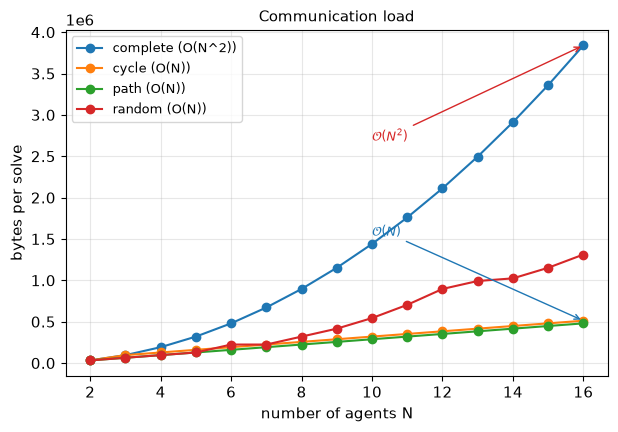

complete (O(N^2)) : bytes ~ N^2.25
cycle (O(N))      : bytes ~ N^1.17


In [3]:
Ns = np.arange(2, 17)
horizon = 10
iterations = 50  # fixed budget so load differences come from topology alone

topologies = {
    "complete (O(N^2))": CommunicationGraph.complete,
    "cycle (O(N))": CommunicationGraph.cycle,
    "path (O(N))": CommunicationGraph.path,
    "random (O(N))": lambda n: CommunicationGraph.random_connected(n, edge_prob=0.4, rng=0),
}

loads = {name: [] for name in topologies}
for name, factory in topologies.items():
    for n in Ns:
        g = factory(n)
        load = communication_load(g, horizon, iterations, float_bytes=8)
        loads[name].append(load["bytes"])

x_values = Ns
ax = plotting.plot_communication_load(loads, x_values, xlabel="number of agents N")
# Annotate the asymptotic gap: complete is quadratic, sparse is linear.
ax.annotate(
    r"$\mathcal{O}(N^2)$",
    xy=(x_values[-1], loads["complete (O(N^2))"][-1]),
    xytext=(x_values[-1] - 6, loads["complete (O(N^2))"][-1] * 0.7),
    fontsize="small",
    arrowprops=dict(arrowstyle="->", color="tab:red"),
    color="tab:red",
)
ax.annotate(
    r"$\mathcal{O}(N)$",
    xy=(x_values[-1], loads["cycle (O(N))"][-1]),
    xytext=(x_values[-1] - 6, loads["cycle (O(N))"][-1] * 3.0),
    fontsize="small",
    arrowprops=dict(arrowstyle="->", color="tab:blue"),
    color="tab:blue",
)
plt.show()

# Direct exponent check: fit bytes ~ N^p on log-log for complete vs cycle.
for name in ("complete (O(N^2))", "cycle (O(N))"):
    p = np.polyfit(np.log(Ns), np.log(loads[name]), 1)[0]
    print(f"{name:18s}: bytes ~ N^{p:.2f}")


## Payload compression

Sending float32 instead of float64, and sending only every other horizon step with linear interpolation. Quantify the accuracy cost of each.

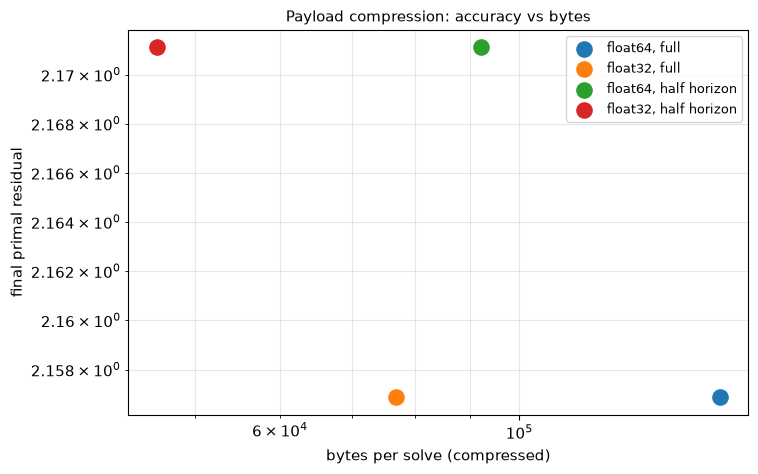

float64, full           :   153600 bytes, residual 2.157e+00
float32, full           :    76800 bytes, residual 2.157e+00
float64, half horizon   :    92160 bytes, residual 2.171e+00
float32, half horizon   :    46080 bytes, residual 2.171e+00


In [4]:
import dataclasses

from distributed_mpc_admm.communication_graph import Message


class CompressingChannel(LossyChannel):
    """Lossless channel that models payload compression.

    ``float_bytes`` selects the payload dtype (8 -> float64, 4 -> float32);
    ``horizon_step`` keeps every ``horizon_step``-th horizon row *on the wire*
    and linearly interpolates back at the receiver. Byte accounting uses the
    actual transmitted (subsampled/quantised) payload size.
    """

    def __init__(self, graph, *, float_bytes=8, horizon_step=1, horizon=None):
        super().__init__(graph, loss_prob=0.0)
        self.float_bytes = int(float_bytes)
        self.horizon_step = int(horizon_step)
        self.horizon = int(horizon) if horizon is not None else None
        self.dtype = np.float64 if self.float_bytes == 8 else np.float32

    def _subsample(self, payload):
        """Reduce the payload to what is actually transmitted."""
        p = np.asarray(payload, dtype=self.dtype)
        if self.horizon_step > 1:
            keep = p[:: self.horizon_step]
            if (p.shape[0] - 1) % self.horizon_step:  # always keep the endpoint
                keep = np.vstack([keep, p[-1:]])
            p = keep
        return p

    def _interpolate(self, payload):
        """Reconstruct the full-horizon payload at the receiver."""
        p = np.asarray(payload, dtype=np.float64)
        if self.horizon_step > 1:
            T = self.horizon if self.horizon is not None else p.shape[0]
            xs = np.arange(T)
            xk = np.arange(0, T, self.horizon_step)
            if xk[-1] != T - 1:
                xk = np.append(xk, T - 1)
            p = np.column_stack(
                [np.interp(xs, xk, p[:, d]) for d in range(p.shape[1])]
            )
        return p

    def send(self, message, iteration):
        payload = self._subsample(message.payload)
        self._stats.sent += 1
        self._stats.bytes_sent += int(payload.nbytes)  # count the *transmitted* size
        if self._rng.random() < self._loss_prob:
            self._stats.dropped += 1
            return False
        delay = int(self._rng.integers(0, self._max_delay + 1))
        compressed = dataclasses.replace(message, payload=payload)
        self._inflight.append((iteration + delay, compressed))
        return True

    def receive(self, receiver, subject, sender, iteration):
        message = super().receive(receiver, subject, sender, iteration)
        if message is None:
            return None
        return dataclasses.replace(message, payload=self._interpolate(message.payload))


def _solve_compressed(graph, horizon, scheme, max_iterations=60):
    channel = CompressingChannel(graph, horizon=horizon, **scheme)
    offs = {i: {j: np.zeros(_model.dim) for j in graph.neighbors(i)} for i in range(graph.n_agents)}
    solvers = _build_solvers(graph, horizon, offsets=offs)
    rng = np.random.default_rng(0)
    x0 = rng.normal(size=(graph.n_agents, _model.n_states))
    x0[:, _model.dim :] *= 0.5
    refs = {i: np.zeros((horizon, _model.dim)) for i in range(graph.n_agents)}
    options = ADMMOptions(max_iterations=max_iterations, eps_abs=0.0, eps_rel=0.0)
    admm = ConsensusADMM(graph, solvers, horizon, _model.dim, options, channel=channel)
    result = admm.solve(x0=x0, references=refs, offsets=offs)
    # Accuracy cost = primal residual at the fixed iteration budget.
    return result.history.primal_residual[-1], channel.stats.bytes_sent


graph = CommunicationGraph.cycle(4)
horizon = 10
schemes = [
    {"float_bytes": 8, "horizon_step": 1},
    {"float_bytes": 4, "horizon_step": 1},
    {"float_bytes": 8, "horizon_step": 2},
    {"float_bytes": 4, "horizon_step": 2},
]
scheme_labels = ["float64, full", "float32, full", "float64, half horizon", "float32, half horizon"]

results = [_solve_compressed(graph, horizon, s) for s in schemes]
errors = np.array([r[0] for r in results])
bytes_per_solve = np.array([r[1] for r in results])

fig, ax = plt.subplots(figsize=(8, 5))
for i, label in enumerate(scheme_labels):
    ax.scatter(bytes_per_solve[i], errors[i], s=120, label=label)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("bytes per solve (compressed)")
ax.set_ylabel("final primal residual")
ax.set_title("Payload compression: accuracy vs bytes")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="best", fontsize="small")
plt.show()

for label, err, nb in zip(scheme_labels, errors, bytes_per_solve, strict=False):
    print(f"{label:24s}: {nb:8d} bytes, residual {err:.3e}")



## Bandwidth envelope

Overlay realistic radio budgets (e.g. a few hundred kB/s for a mesh link) and read off the largest feasible (N, T, iteration budget) triple.

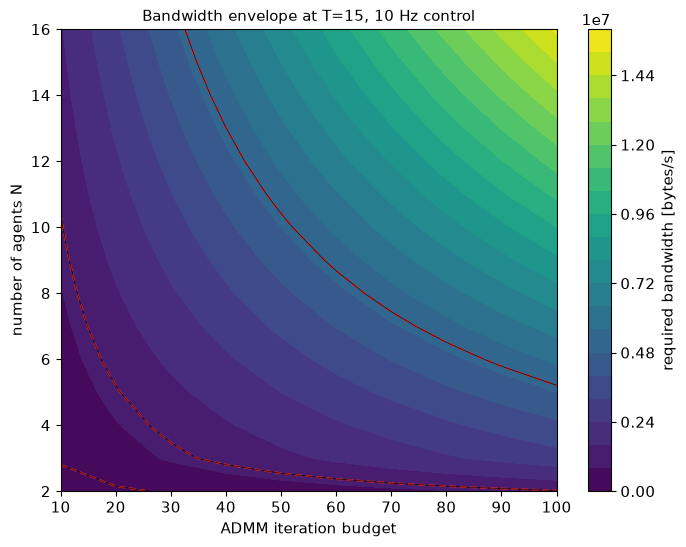

at 250 kB/s the largest N with any iteration budget is 2


In [5]:
# Required bandwidth = bytes per solve / control period. Sweep N and the iteration
# budget at a fixed horizon, then contour it against a few realistic radio budgets.
T = 15
period = 0.1  # 10 Hz control loop
Ns = np.arange(2, 17)
iter_budgets = np.arange(10, 101, 10)

bandwidth = np.zeros((len(Ns), len(iter_budgets)))
for i, n in enumerate(Ns):
    g = CommunicationGraph.cycle(n)
    for j, it in enumerate(iter_budgets):
        load = communication_load(g, T, it, float_bytes=8)
        bandwidth[i, j] = load["bytes"] / period  # bytes/s

X, Y = np.meshgrid(iter_budgets, Ns)
fig, ax = plt.subplots(figsize=(8, 6))
cs = ax.contourf(X, Y, bandwidth, levels=20, cmap="viridis")
cbar = fig.colorbar(cs, ax=ax)
cbar.set_label("required bandwidth [bytes/s]")

# Realistic mesh-radio envelopes (e.g. 802.15.4 ~ 250 kB/s; WiFi ~ 5 MB/s).
for rate in (250e3, 1e6, 5e6):
    ax.contour(X, Y, bandwidth, levels=[rate], colors=["tab:red", "tab:orange", "white"],
               linewidths=1.4, linestyles="--")
    ax.contour(X, Y, bandwidth, levels=[rate], colors=["black"], linewidths=0.4)

ax.set_xlabel("ADMM iteration budget")
ax.set_ylabel("number of agents N")
ax.set_title(f"Bandwidth envelope at T={T}, 10 Hz control")
plt.show()

# Read off the largest feasible (N, iterations) triple for the lowest budget.
feasible = bandwidth <= 250e3
Ns_feasible = Ns[feasible.any(axis=1)]
print(f"at 250 kB/s the largest N with any iteration budget is {Ns_feasible.max() if Ns_feasible.size else None}")


## Takeaway

Sparse topologies keep bandwidth linear in N; the horizon, not the agent count, dominates payload size.